In [1]:
# Optional: install/reinstall deps in Kaggle
# %pip install -q numpy pandas scikit-learn joblib torch tqdm pyyaml matplotlib

In [2]:
import json
import math
import random
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ===== User config =====
DATA_DIR = Path('/kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files') 
OUTPUT_DIR = Path('/kaggle/working/artifacts_standalone')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    raise FileNotFoundError(f'DATA_DIR not found: {DATA_DIR}')

SEED = 42
POLL_INTERVAL_SECONDS = 3
WINDOW_SIZE = 30
FORECAST_HORIZON_SECONDS = 30
HORIZON_STEPS = max(1, FORECAST_HORIZON_SECONDS // POLL_INTERVAL_SECONDS)

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

# GPU-aware defaults for Kaggle
USE_CUDA = torch.cuda.is_available()
BATCH_SIZE = 256 if USE_CUDA else 128
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 8

FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0
MAX_FPR = 0.05

NUM_WORKERS = 4 if USE_CUDA else 2
PIN_MEMORY = USE_CUDA
PERSISTENT_WORKERS = NUM_WORKERS > 0
USE_AMP = USE_CUDA

DEVICE = torch.device('cuda' if USE_CUDA else 'cpu')

# Memory guards for large datasets on Kaggle
MEMORY_SAFE_MODE = True
MAX_FILES = None  # e.g. 6 for quick tests
RAW_NROWS_PER_FILE = 800_000 if MEMORY_SAFE_MODE else None
ENGINEERED_SAMPLE_FRAC = 1.0  # e.g. 0.5 to keep 50% after feature engineering
MAX_TOTAL_ENGINEERED_ROWS = 2_500_000 if MEMORY_SAFE_MODE else None

# CUDA runtime tuning
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

print('Using DEVICE:', DEVICE)
print('BATCH_SIZE:', BATCH_SIZE)
print('NUM_WORKERS:', NUM_WORKERS, 'PIN_MEMORY:', PIN_MEMORY, 'USE_AMP:', USE_AMP)
print('MEMORY_SAFE_MODE:', MEMORY_SAFE_MODE)
print('RAW_NROWS_PER_FILE:', RAW_NROWS_PER_FILE, 'MAX_TOTAL_ENGINEERED_ROWS:', MAX_TOTAL_ENGINEERED_ROWS)

Using DEVICE: cuda
BATCH_SIZE: 256
NUM_WORKERS: 4 PIN_MEMORY: True USE_AMP: True
MEMORY_SAFE_MODE: True
RAW_NROWS_PER_FILE: 800000 MAX_TOTAL_ENGINEERED_ROWS: 2500000


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

M2_FEATURES = [
    'pkt_rate', 'byte_rate', 'syn_rate', 'src_ip_entropy', 'dst_ip_entropy',
    'pkt_len_mean', 'pkt_len_std', 'flow_rate', 'iat_mean', 'iat_std',
    'tcp_flag_ratio', 'retry_rate', 'icmp_rate', 'udp_rate', 'http_rate'
]

TIME_CANDIDATES = ['Timestamp', 'timestamp', 'Time', 'time', 'Date', 'date']


def list_csv_files(data_dir: Path):
    files = sorted(data_dir.rglob('*.csv'))
    if MAX_FILES is not None:
        files = files[:MAX_FILES]
    return files


def detect_timestamp_column(df: pd.DataFrame, preferred: Optional[str] = 'Timestamp'):
    if preferred and preferred in df.columns:
        return preferred
    for c in TIME_CANDIDATES:
        if c in df.columns:
            return c
    raise ValueError('No timestamp column found')


def pick_first_existing(df: pd.DataFrame, candidates: list[str]):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def to_num(df: pd.DataFrame, col: Optional[str], default=0.0):
    if col is None:
        return pd.Series(default, index=df.index, dtype='float64')
    return pd.to_numeric(df[col], errors='coerce').fillna(default)


def shannon_entropy(values: pd.Series) -> float:
    if values.empty:
        return 0.0
    probs = values.value_counts(normalize=True, dropna=True).to_numpy()
    if probs.size == 0:
        return 0.0
    return float(-(probs * np.log2(probs + 1e-12)).sum())


def optimize_numeric_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_float_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], downcast='float')
        elif pd.api.types.is_integer_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], downcast='integer')
    return out


def build_features_for_csv(path: Path, raw_nrows: Optional[int] = None) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=True, on_bad_lines='skip', nrows=raw_nrows)
    df.columns = [c.strip() for c in df.columns]

    ts_col = detect_timestamp_column(df, 'Timestamp')
    if 'Label' not in df.columns:
        raise ValueError(f'Label column missing in {path}')

    fwd_pkt_col = pick_first_existing(df, ['Total Fwd Packets', 'Tot Fwd Pkts'])
    bwd_pkt_col = pick_first_existing(df, ['Total Backward Packets', 'Tot Bwd Pkts'])
    fwd_len_col = pick_first_existing(df, ['Total Length of Fwd Packets', 'TotLen Fwd Pkts'])
    bwd_len_col = pick_first_existing(df, ['Total Length of Bwd Packets', 'TotLen Bwd Pkts'])
    flow_dur_col = pick_first_existing(df, ['Flow Duration'])
    flow_pkt_rate_col = pick_first_existing(df, ['Flow Packets/s'])
    flow_byte_rate_col = pick_first_existing(df, ['Flow Bytes/s'])

    syn_col = pick_first_existing(df, ['SYN Flag Count'])
    rst_col = pick_first_existing(df, ['RST Flag Count'])
    ack_col = pick_first_existing(df, ['ACK Flag Count'])
    fin_col = pick_first_existing(df, ['FIN Flag Count'])
    psh_col = pick_first_existing(df, ['PSH Flag Count'])
    urg_col = pick_first_existing(df, ['URG Flag Count'])

    pkt_len_mean_col = pick_first_existing(df, ['Packet Length Mean', 'Average Packet Size'])
    pkt_len_std_col = pick_first_existing(df, ['Packet Length Std', 'Pkt Len Std'])
    iat_mean_col = pick_first_existing(df, ['Flow IAT Mean'])
    iat_std_col = pick_first_existing(df, ['Flow IAT Std'])

    src_ip_col = pick_first_existing(df, ['Source IP', 'Src IP', 'Src_IP'])
    dst_ip_col = pick_first_existing(df, ['Destination IP', 'Dst IP', 'Dst_IP'])
    proto_col = pick_first_existing(df, ['Protocol'])
    dport_col = pick_first_existing(df, ['Destination Port', 'Dst Port', 'Dst_Port'])

    duration_us = to_num(df, flow_dur_col, 1.0).clip(lower=1.0)
    duration_s = duration_us / 1_000_000.0

    total_pkts = to_num(df, fwd_pkt_col) + to_num(df, bwd_pkt_col)
    total_bytes = to_num(df, fwd_len_col) + to_num(df, bwd_len_col)

    pkt_rate = to_num(df, flow_pkt_rate_col)
    if flow_pkt_rate_col is None:
        pkt_rate = total_pkts / (duration_s.abs() + 1e-9)

    byte_rate = to_num(df, flow_byte_rate_col)
    if flow_byte_rate_col is None:
        byte_rate = total_bytes / (duration_s.abs() + 1e-9)

    syn_rate = to_num(df, syn_col) / (duration_s.abs() + 1e-9)

    tcp_flag_sum = to_num(df, syn_col) + to_num(df, ack_col) + to_num(df, fin_col) + to_num(df, psh_col) + to_num(df, urg_col) + to_num(df, rst_col)
    tcp_flag_ratio = (tcp_flag_sum / (total_pkts.replace(0, np.nan))).fillna(0.0)
    retry_rate = to_num(df, rst_col) / (duration_s.abs() + 1e-9)

    parsed_ts = pd.to_datetime(df[ts_col], errors='coerce', dayfirst=True)
    labels = df['Label'].astype(str).str.lower().str.strip()
    attack_binary = (~labels.str.contains('benign|normal', regex=True, na=False)).astype(int)

    engineered = pd.DataFrame({
        'timestamp': parsed_ts,
        'attack_binary': attack_binary,
        'pkt_rate': pkt_rate,
        'byte_rate': byte_rate,
        'syn_rate': syn_rate,
        'pkt_len_mean': to_num(df, pkt_len_mean_col),
        'pkt_len_std': to_num(df, pkt_len_std_col),
        'iat_mean': to_num(df, iat_mean_col),
        'iat_std': to_num(df, iat_std_col),
        'tcp_flag_ratio': tcp_flag_ratio,
        'retry_rate': retry_rate,
    })

    proto = to_num(df, proto_col, -1)
    dport = to_num(df, dport_col, -1)
    engineered['is_icmp'] = (proto == 1).astype(float)
    engineered['is_udp'] = (proto == 17).astype(float)
    engineered['is_http'] = ((dport == 80) | (dport == 443) | (dport == 8080)).astype(float)
    engineered['_src_ip'] = df[src_ip_col].astype(str) if src_ip_col else 'unknown'
    engineered['_dst_ip'] = df[dst_ip_col].astype(str) if dst_ip_col else 'unknown'

    engineered = engineered.dropna(subset=['timestamp']).sort_values('timestamp').set_index('timestamp')
    freq = f'{POLL_INTERVAL_SECONDS}s'

    stat_cols = ['pkt_rate', 'byte_rate', 'syn_rate', 'pkt_len_mean', 'pkt_len_std', 'iat_mean', 'iat_std', 'tcp_flag_ratio', 'retry_rate']
    agg_stats = engineered[stat_cols].resample(freq).mean()
    attack = engineered[['attack_binary']].resample(freq).max()

    flow_count = engineered[['attack_binary']].resample(freq).size().rename('flow_count')
    flow_rate = (flow_count / float(POLL_INTERVAL_SECONDS)).rename('flow_rate')

    icmp_rate = (engineered[['is_icmp']].resample(freq).sum()['is_icmp'] / float(POLL_INTERVAL_SECONDS)).rename('icmp_rate')
    udp_rate = (engineered[['is_udp']].resample(freq).sum()['is_udp'] / float(POLL_INTERVAL_SECONDS)).rename('udp_rate')
    http_rate = (engineered[['is_http']].resample(freq).sum()['is_http'] / float(POLL_INTERVAL_SECONDS)).rename('http_rate')

    src_entropy = engineered['_src_ip'].resample(freq).apply(shannon_entropy).rename('src_ip_entropy')
    dst_entropy = engineered['_dst_ip'].resample(freq).apply(shannon_entropy).rename('dst_ip_entropy')

    out = pd.concat([agg_stats, src_entropy, dst_entropy, flow_rate, icmp_rate, udp_rate, http_rate, attack], axis=1)
    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index()
    out = out[['timestamp'] + M2_FEATURES + ['attack_binary']]

    if ENGINEERED_SAMPLE_FRAC < 1.0:
        out = out.sample(frac=ENGINEERED_SAMPLE_FRAC, random_state=SEED).sort_values('timestamp').reset_index(drop=True)

    return optimize_numeric_dtypes(out)


def load_and_resample_all(
    data_dir: Path,
    raw_nrows_per_file: Optional[int] = None,
    max_total_rows: Optional[int] = None,
) -> pd.DataFrame:
    files = list_csv_files(data_dir)
    if not files:
        raise FileNotFoundError(f'No CSV found under {data_dir}')

    frames = []
    running_rows = 0

    for p in tqdm(files, desc='Reading CSVs'):
        try:
            part = build_features_for_csv(p, raw_nrows=raw_nrows_per_file)
            frames.append(part)
            running_rows += len(part)

            # If buffer grows too much, compact immediately to keep RAM bounded.
            if max_total_rows is not None and running_rows > int(max_total_rows * 1.2):
                merged = pd.concat(frames, ignore_index=True)
                merged = optimize_numeric_dtypes(merged)
                merged = merged.sample(n=max_total_rows, random_state=SEED).sort_values('timestamp').reset_index(drop=True)
                frames = [merged]
                running_rows = len(merged)
        except Exception as e:
            print(f'[WARN] Skip {p.name}: {e}')

    if not frames:
        raise RuntimeError('No valid CSV processed successfully')

    all_df = pd.concat(frames, ignore_index=True)
    all_df = optimize_numeric_dtypes(all_df)

    if max_total_rows is not None and len(all_df) > max_total_rows:
        all_df = all_df.sample(n=max_total_rows, random_state=SEED).sort_values('timestamp').reset_index(drop=True)

    all_df = all_df.sort_values('timestamp').reset_index(drop=True)
    return all_df


df_all = load_and_resample_all(
    DATA_DIR,
    raw_nrows_per_file=RAW_NROWS_PER_FILE,
    max_total_rows=MAX_TOTAL_ENGINEERED_ROWS,
)
print(df_all.shape)
display(df_all.head())

Reading CSVs:   0%|          | 0/18 [00:00<?, ?it/s]

/tmp/ipykernel_25/3159524035.py:68: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, low_memory=True, on_bad_lines='skip', nrows=raw_nrows)
/tmp/ipykernel_25/3159524035.py:68: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, low_memory=True, on_bad_lines='skip', nrows=raw_nrows)
/tmp/ipykernel_25/3159524035.py:68: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, low_memory=True, on_bad_lines='skip', nrows=raw_nrows)
/tmp/ipykernel_25/3159524035.py:68: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, low_memory=True, on_bad_lines='skip', nrows=raw_nrows)
/tmp/ipykernel_25/3159524035.py:68: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=Fa

(8461, 17)


,timestamp,pkt_rate,byte_rate,syn_rate,src_ip_entropy,dst_ip_entropy,pkt_len_mean,pkt_len_std,flow_rate,iat_mean,iat_std,tcp_flag_ratio,retry_rate,icmp_rate,udp_rate,http_rate,attack_binary
0,2018-01-12 09:17:09,2.287962,5.954939e+02,0.000000,-1.442823e-12,-1.442823e-12,141.318176,212.014297,0.666667,1.184210e+06,3.139666e+06,0.095238,0.000000,0.0,0.0,0.666667,1.0
1,2018-01-12 09:17:12,190476.540017,8.533471e+00,95206.359785,1.378783e+00,2.521641e+00,16.966667,67.771233,2.333333,1.526688e+06,2.886054e+06,0.312461,0.000000,0.0,0.0,1.333333,0.0
2,2018-01-12 09:17:15,208589.185546,1.157945e+02,99950.024988,1.921928e+00,1.921928e+00,36.250000,74.140244,1.666667,6.592185e+05,1.144717e+06,0.380000,0.000000,0.0,0.0,0.666667,1.0
3,2018-01-12 09:17:18,610958.363273,6.361688e+06,99950.024988,1.521928e+00,1.521928e+00,12.960000,10.777236,1.666667,4.718333e+01,7.460166e+01,0.606667,200658.565215,0.0,0.0,0.666667,0.0
4,2018-01-12 09:17:21,19372.242623,0.000000e+00,0.000000,1.000000e+00,1.000000e+00,0.000000,0.000000,1.333333,1.302500e+02,3.535534e+01,0.416667,0.000000,0.0,0.0,0.666667,1.0


In [4]:
def build_sequences(frame: pd.DataFrame, feature_cols: list[str], window_size: int, horizon_steps: int):
    X, y = [], []
    ts_now, ts_target = [], []
    features = frame[feature_cols].to_numpy(dtype=np.float32)
    labels = frame['attack_binary'].to_numpy(dtype=np.float32)
    ts = pd.to_datetime(frame['timestamp']).to_numpy()

    max_i = len(frame) - horizon_steps
    for i in range(window_size - 1, max_i):
        start = i - window_size + 1
        X.append(features[start:i+1])
        y.append(labels[i + horizon_steps])
        ts_now.append(ts[i])
        ts_target.append(ts[i + horizon_steps])

    return {
        'X': np.asarray(X, dtype=np.float32),
        'y': np.asarray(y, dtype=np.float32),
        'ts_now': np.asarray(ts_now),
        'ts_target': np.asarray(ts_target),
    }

def chronological_split(X, y, ts_now, ts_target, train_ratio=0.7, val_ratio=0.15):
    n = len(X)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    idx_train = slice(0, n_train)
    idx_val = slice(n_train, n_train + n_val)
    idx_test = slice(n_train + n_val, n)

    return {
        'train': {'X': X[idx_train], 'y': y[idx_train], 'ts_now': ts_now[idx_train], 'ts_target': ts_target[idx_train]},
        'val': {'X': X[idx_val], 'y': y[idx_val], 'ts_now': ts_now[idx_val], 'ts_target': ts_target[idx_val]},
        'test': {'X': X[idx_test], 'y': y[idx_test], 'ts_now': ts_now[idx_test], 'ts_target': ts_target[idx_test]},
    }

def fit_scale_transform(split: dict):
    scaler = StandardScaler()
    X_train = split['train']['X']
    b, w, f = X_train.shape
    scaler.fit(X_train.reshape(b * w, f))

    for key in ['train', 'val', 'test']:
        X = split[key]['X']
        b, w, f = X.shape
        split[key]['X'] = scaler.transform(X.reshape(b * w, f)).reshape(b, w, f).astype(np.float32)

    return scaler

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'X': self.X[idx], 'y': self.y[idx]}

seq = build_sequences(df_all, M2_FEATURES, WINDOW_SIZE, HORIZON_STEPS)
split = chronological_split(seq['X'], seq['y'], seq['ts_now'], seq['ts_target'], TRAIN_RATIO, VAL_RATIO)
scaler = fit_scale_transform(split)

print('Train shape:', split['train']['X'].shape, split['train']['y'].shape)
print('Val shape:', split['val']['X'].shape, split['val']['y'].shape)
print('Test shape:', split['test']['X'].shape, split['test']['y'].shape)

Train shape: (5895, 30, 15) (5895,)
Val shape: (1263, 30, 15) (1263,)
Test shape: (1264, 30, 15) (1264,)


In [5]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x if self.chomp_size == 0 else x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.utils.weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.utils.weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.drop1, self.conv2, self.chomp2, self.relu2, self.drop2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCNBinaryPredictor(nn.Module):
    def __init__(self, in_features, channels=(64,64,32), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = in_features
        for i, out_ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, 2 ** i, dropout))
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], 1)

    def forward(self, x):
        # Return logits (not probabilities) for AMP-safe BCEWithLogits-style loss.
        x = x.transpose(1, 2)
        z = self.tcn(x)
        z_last = z[:, :, -1]
        return self.head(z_last).squeeze(-1)

class LSTMBinaryPredictor(nn.Module):
    def __init__(self, in_features, hidden_size=128, num_layers=2, dropout=0.2, bidirectional=False):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=in_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=effective_dropout,
            bidirectional=bidirectional,
            batch_first=True,
        )
        out_dim = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Linear(out_dim, 1)

    def forward(self, x):
        # Return logits (not probabilities) for AMP-safe BCEWithLogits-style loss.
        z, _ = self.lstm(x)
        z_last = z[:, -1, :]
        return self.head(z_last).squeeze(-1)

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = alpha_t * torch.pow((1 - p_t), self.gamma) * bce
        return focal.mean()

def threshold_search_under_fpr(y_true, y_prob, max_fpr=0.05, num_steps=200):
    best_thr = 0.5
    best_f1 = -1.0
    best_stats = {}
    for thr in np.linspace(0.01, 0.99, num_steps):
        y_pred = (y_prob >= thr).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        tn = int(((y_pred == 0) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        fpr = fp / (fp + tn + 1e-12)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if fpr <= max_fpr and f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
            best_stats = {'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn, 'fpr': float(fpr), 'f1': float(f1)}

    if best_f1 < 0:
        y_pred = (y_prob >= 0.5).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        tn = int(((y_pred == 0) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        fpr = fp / (fp + tn + 1e-12)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        best_thr = 0.5
        best_stats = {'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn, 'fpr': float(fpr), 'f1': float(f1)}

    return best_thr, best_stats

def binary_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fpr = fp / (fp + tn + 1e-12)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan')
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(auc),
        'fpr': float(fpr),
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    }

In [6]:
def run_epoch(model, loader, criterion, optimizer=None, amp_scaler=None, device=DEVICE, use_amp=USE_AMP):
    is_train = optimizer is not None
    model.train(is_train)
    losses, probs, trues = [], [], []

    amp_dtype = torch.float16 if device.type == 'cuda' else torch.float32

    for batch in loader:
        x = batch['X'].to(device, non_blocking=True)
        y = batch['y'].to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        if is_train:
            if amp_scaler is not None:
                amp_scaler.scale(loss).backward()
                amp_scaler.step(optimizer)
                amp_scaler.update()
            else:
                loss.backward()
                optimizer.step()

        prob = torch.sigmoid(logits)
        losses.append(float(loss.item()))
        probs.append(prob.detach().cpu().numpy())
        trues.append(y.detach().cpu().numpy())

    y_prob = np.concatenate(probs)
    y_true = np.concatenate(trues).astype(int)
    return float(np.mean(losses)), y_true, y_prob


def train_one_model(model_type: str):
    model_dir = OUTPUT_DIR / f'm1_{model_type}'
    model_dir.mkdir(parents=True, exist_ok=True)

    train_ds = SequenceDataset(split['train']['X'], split['train']['y'])
    val_ds = SequenceDataset(split['val']['X'], split['val']['y'])
    test_ds = SequenceDataset(split['test']['X'], split['test']['y'])

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
    )

    in_features = len(M2_FEATURES)
    if model_type == 'tcn':
        model = TCNBinaryPredictor(in_features=in_features, channels=(64, 64, 32), kernel_size=3, dropout=0.2).to(DEVICE)
        model_cfg = {'tcn_channels': [64, 64, 32], 'tcn_kernel_size': 3, 'tcn_dropout': 0.2}
    elif model_type == 'lstm':
        model = LSTMBinaryPredictor(in_features=in_features, hidden_size=128, num_layers=2, dropout=0.2, bidirectional=False).to(DEVICE)
        model_cfg = {'lstm_hidden_size': 128, 'lstm_num_layers': 2, 'lstm_dropout': 0.2, 'lstm_bidirectional': False}
    else:
        raise ValueError(f'Unsupported model_type: {model_type}')

    criterion = BinaryFocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    amp_scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    best_state = None
    best_val_loss = float('inf')
    wait = 0
    history = []

    for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc=f'Training {model_type.upper()}'):
        train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer, amp_scaler=amp_scaler, device=DEVICE, use_amp=USE_AMP)
        val_loss, y_val, p_val = run_epoch(model, val_loader, criterion, None, amp_scaler=None, device=DEVICE, use_amp=USE_AMP)

        thr, _ = threshold_search_under_fpr(y_val, p_val, max_fpr=MAX_FPR)
        val_m = binary_metrics(y_val, p_val, thr)
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_threshold': thr,
            'val_f1': val_m['f1'],
            'val_fpr': val_m['fpr'],
            'val_auc': val_m['roc_auc'],
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= EARLY_STOPPING_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError('No best state saved')

    model.load_state_dict(best_state)

    _, y_val, p_val = run_epoch(model, val_loader, criterion, None, amp_scaler=None, device=DEVICE, use_amp=USE_AMP)
    best_thr, thr_stats = threshold_search_under_fpr(y_val, p_val, max_fpr=MAX_FPR)

    _, y_test, p_test = run_epoch(model, test_loader, criterion, None, amp_scaler=None, device=DEVICE, use_amp=USE_AMP)
    test_metrics = binary_metrics(y_test, p_test, best_thr)

    ckpt = {
        'model_state': model.state_dict(),
        'model_type': model_type,
        'feature_columns': M2_FEATURES,
        'threshold': float(best_thr),
        'window_size': WINDOW_SIZE,
        'horizon_steps': HORIZON_STEPS,
        'poll_interval_seconds': POLL_INTERVAL_SECONDS,
        **model_cfg
    }

    torch.save(ckpt, model_dir / 'model.pt')
    joblib.dump(scaler, model_dir / 'scaler.joblib')

    with open(model_dir / 'test_metrics.json', 'w', encoding='utf-8') as f:
        json.dump(test_metrics, f, indent=2)

    with open(model_dir / 'training_history.json', 'w', encoding='utf-8') as f:
        json.dump({'history': history}, f, indent=2)

    with open(model_dir / 'threshold_stats.json', 'w', encoding='utf-8') as f:
        json.dump(thr_stats, f, indent=2)

    pred_df = pd.DataFrame({
        'ts_now': split['test']['ts_now'].astype(str),
        'ts_target': split['test']['ts_target'].astype(str),
        'y_true': y_test,
        'y_prob': p_test,
        'y_pred': (p_test >= best_thr).astype(int)
    })
    pred_df.to_csv(model_dir / 'eval_predictions.csv', index=False)

    with torch.no_grad():
        x_t = torch.from_numpy(split['test']['X']).to(DEVICE, non_blocking=True)
        y_t = torch.from_numpy(split['test']['y']).to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16 if DEVICE.type == 'cuda' else torch.float32, enabled=USE_AMP):
            test_logits = model(x_t)
            loss = criterion(test_logits, y_t).item()

    eval_metrics = dict(test_metrics)
    with open(model_dir / 'eval_metrics.json', 'w', encoding='utf-8') as f:
        json.dump(eval_metrics, f, indent=2)
    with open(model_dir / 'eval_loss.json', 'w', encoding='utf-8') as f:
        json.dump({'focal_loss': float(loss)}, f, indent=2)

    return {'model': model_type, **test_metrics, 'model_dir': str(model_dir)}


res_tcn = train_one_model('tcn')
res_lstm = train_one_model('lstm')
print('Done training both models')

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Training TCN:   0%|          | 0/30 [00:00<?, ?it/s]

Training LSTM:   0%|          | 0/30 [00:00<?, ?it/s]

Done training both models


,model,f1,roc_auc,fpr,precision,recall,accuracy
0,lstm,0.131351,0.546702,0.055556,0.638554,0.073204,0.445411
1,tcn,0.075227,0.510926,0.033333,0.617021,0.040055,0.435918


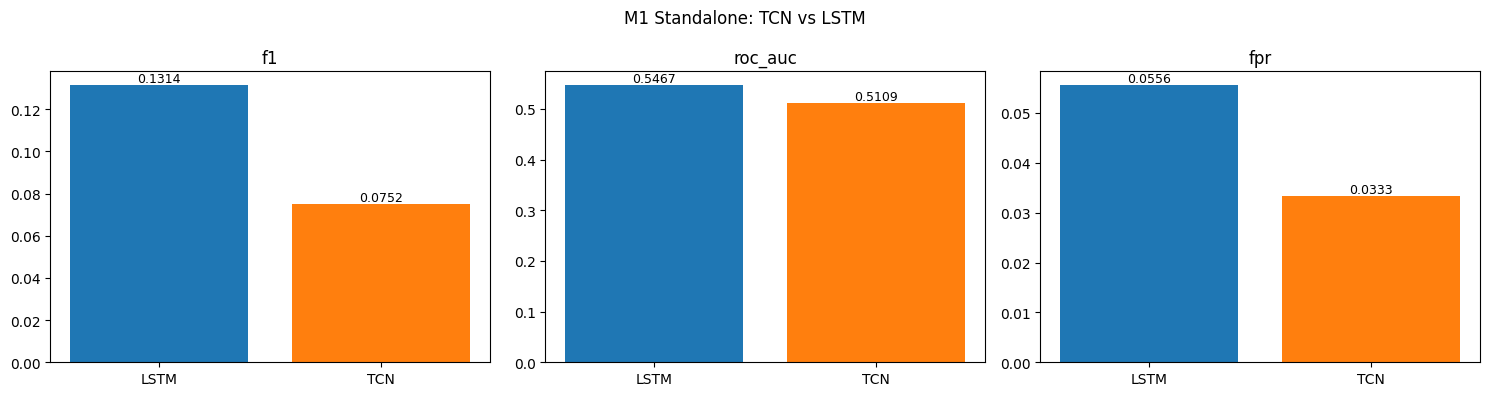

Saved outputs under: /kaggle/working/artifacts_standalone
Zip: /kaggle/working/m1_standalone_artifacts.zip


In [7]:
comparison = pd.DataFrame([res_tcn, res_lstm])[['model', 'f1', 'roc_auc', 'fpr', 'precision', 'recall', 'accuracy']]
comparison = comparison.sort_values('f1', ascending=False).reset_index(drop=True)
display(comparison)

comparison.to_csv(OUTPUT_DIR / 'm1_model_comparison.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['f1', 'roc_auc', 'fpr']
for ax, m in zip(axes, metrics):
    ax.bar(comparison['model'].str.upper(), comparison[m], color=['#1f77b4', '#ff7f0e'])
    ax.set_title(m)
    for i, v in enumerate(comparison[m]):
        ax.text(i, float(v), f'{float(v):.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('M1 Standalone: TCN vs LSTM')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'm1_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

latex_df = comparison.copy()
latex_df['model'] = latex_df['model'].str.upper()
latex = latex_df.to_latex(index=False, float_format='%.4f', caption='M1 standalone model comparison', label='tab:m1_standalone_compare')
(OUTPUT_DIR / 'm1_model_comparison_table.tex').write_text(latex, encoding='utf-8')

zip_path = shutil.make_archive('/kaggle/working/m1_standalone_artifacts', 'zip', root_dir=str(OUTPUT_DIR))
print('Saved outputs under:', OUTPUT_DIR)
print('Zip:', zip_path)